In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp
import deepssfp.analysis

In [3]:
modes=['BandRemoval:4', 'BandRemoval:2', 'SuperFOV', 'SuperFOVi', 'SyntheticBanding']
model_dir = "D:/DeepSSFP/"
model_name='finetuned' #"phantom_metrics"

In [ ]:
save_path = f"D:/DeepSSFP/phantom_data.npy"
if save_path and os.path.isfile(save_path):
    print(f'Saved dataset found. Loading from file: {save_path}')
    data = np.load(save_path, allow_pickle=True)
    rawdata =  np.concatenate([ data[0]['M'], data[1]['M']], axis=0)
else:
    print("Generating dataset...")
    rawdata_block = deepssfp.analysis.create_block_rawdata()
    rawdata_brain = deepssfp.analysis.create_brain_rawdata()
    rawdata =  np.concatenate([ rawdata_block['M'], rawdata_brain['M']], axis=0)
    
    _data = [ { 'M': rawdata_block['M'], 'seg': rawdata_block['seg'] }, { 'M': rawdata_brain['M'], 'seg': rawdata_brain['seg'] } ]
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    np.save(save_path, _data)

print(rawdata.shape)

Saved dataset found. Loading from file: D:/DeepSSFP/phantom_data.npy
(960, 256, 256, 4)


In [4]:
outputs = {}
for mode in deepssfp.dataset.modes:
    print(f"\n===== Training: {mode} =====")
    ds = deepssfp.dataset.Dataset(mode, input_data=rawdata)
    model_dict = deepssfp.analysis.run_training(ds, mode, model_name, model_dir, train_model=True, epochs=800, verbose=False)
    pred, target = deepssfp.analysis.run_inference_on_test_dataset(ds, model_dict['model'], verbose=False)
    metrics = deepssfp.analysis.compute_image_metrics(pred, target, verbose=True)
    outputs[mode] = metrics


===== Training: BandRemoval:4 =====
Dataset: mode:BandRemoval:4, size:960 height:256 width:256 cin:8 cout:2 ratio:0.8 dtype: float64, float64


2025-06-06 23:55:13,847 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/finetuned_bandremoval_4
2025-06-06 23:55:13,869 - DeepSSFP - INFO - Training DataSet: (768, 256, 256, 8) | (768, 256, 256, 2)
2025-06-06 23:55:13,870 - DeepSSFP - INFO - Test DataSet: (192, 256, 256, 8) | (192, 256, 256, 2)
2025-06-06 23:55:15,724 - DeepSSFP - INFO - Creating new model with dimensions: 256x256x8→2
2025-06-06 23:55:20,481 - DeepSSFP - INFO - Model created: unet


Model: "unet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 256, 256, 8) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 256, 256, 32) 2336        img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 256, 256, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 256, 256, 32) 128         conv2d_1[0][0]                   
_______________________________________________________________________________________________

2025-06-07 00:25:34,872 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/finetuned_bandremoval_4.keras


6/6 [==============================] - 4s 78ms/step - loss: 0.0034 - mean_absolute_error: 0.0303


...

Model: "unet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 256, 256, 2) 0                                            
__________________________________________________________________________________________________
conv2d_57 (Conv2D)              (None, 256, 256, 32) 608         img[0][0]                        
__________________________________________________________________________________________________
conv2d_58 (Conv2D)              (None, 256, 256, 32) 9248        conv2d_57[0][0]                  
__________________________________________________________________________________________________
batch_normalization_27 (BatchNo (None, 256, 256, 32) 128         conv2d_58[0][0]                  
_______________________________________________________________________________________________

2025-06-07 13:10:29,979 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/finetuned_superfov.keras


6/6 [==============================] - 1s 71ms/step - loss: 0.1101 - mean_absolute_error: 0.1378


2025-06-07 13:10:31,931 - DeepSSFP - INFO - Training Complete. Loss: 0.1101, MAE: 0.1378
2025-06-07 13:10:31,932 - DeepSSFP - INFO - Time Elapsed: 13427.14 seconds
2025-06-07 13:10:32,176 - DeepSSFP - INFO - Making predictions on data with shape (192, 256, 256, 2)
2025-06-07 13:10:32,835 - DeepSSFP - INFO - Predictions complete. Output shape: (192, 256, 256, 2)


mse: 4.94e-04 +/- 1.18e-04 mae: 1.60e-02 +/- 2.36e-03 psnr: 17.7659 +/- 9.82e-01 ssim: 4.33e-01 +/- 2.35e-02 nrmse: 2.68e-01 +/- 3.11e-02 



===== Results: BandRemoval:4 =====


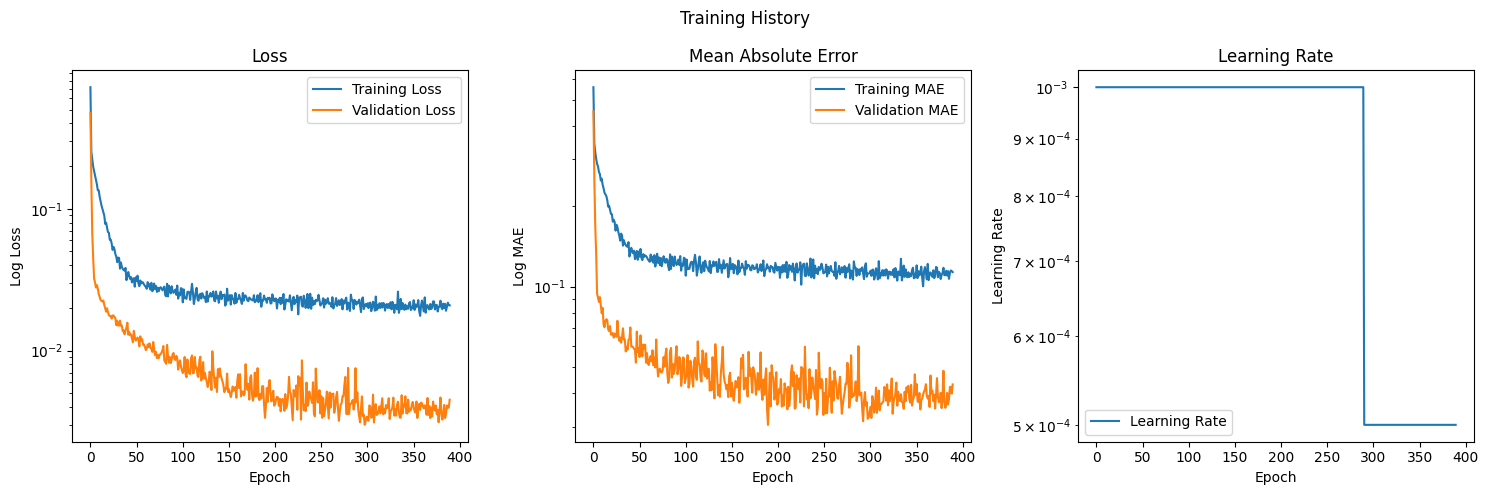


===== Results: BandRemoval:2 =====


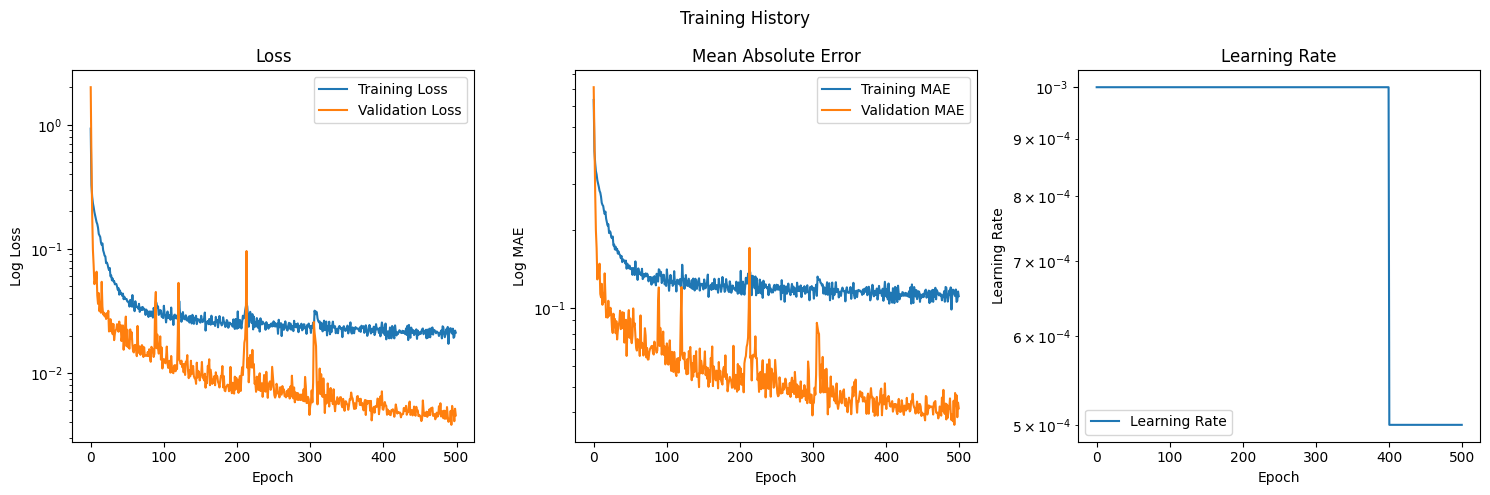


===== Results: SyntheticBanding =====


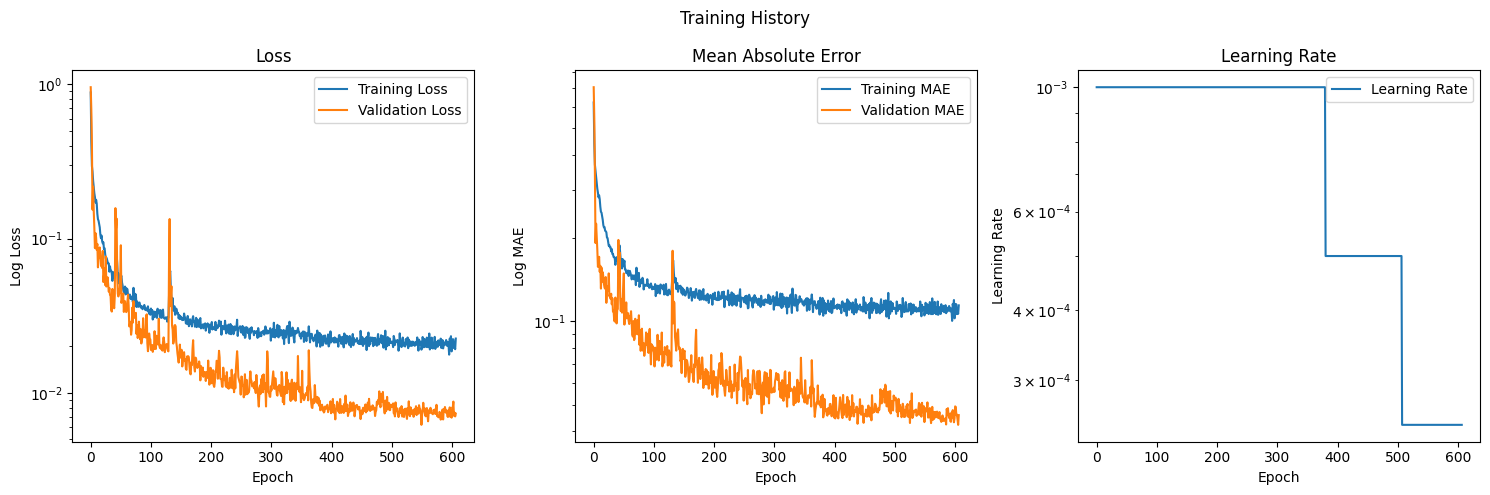


===== Results: SuperFOV =====


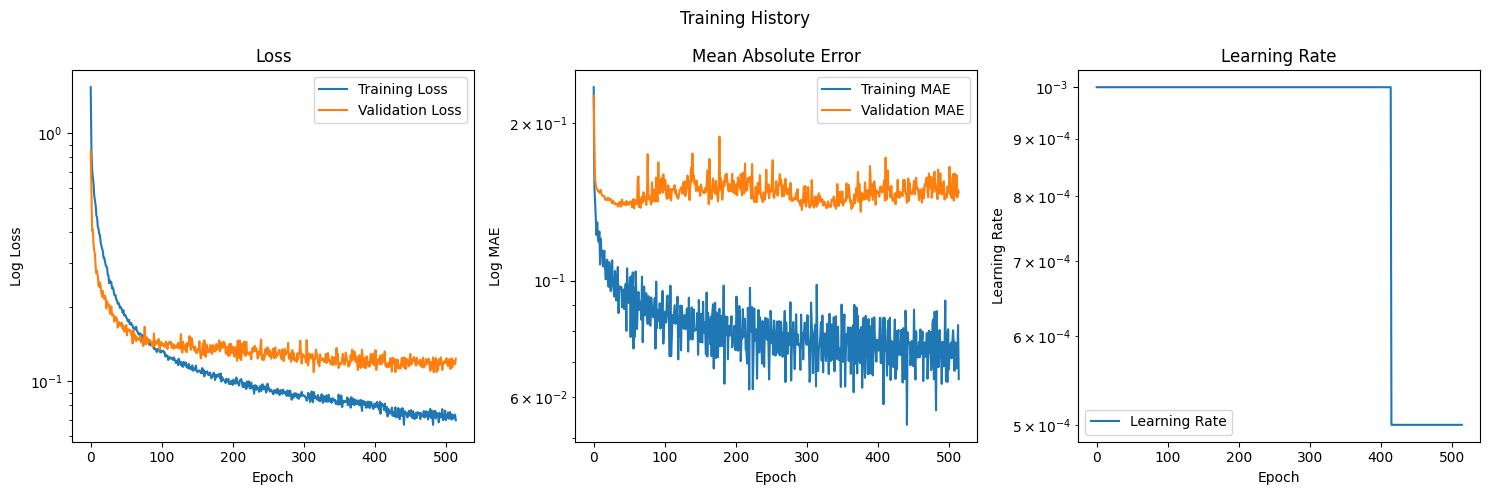

In [8]:
outputs = {}
for mode in deepssfp.dataset.modes:
    print(f"\n===== Results: {mode} =====")
    pass

    model_path = os.path.join(model_dir, f"{model_name}_{mode.lower().replace(':', '_')}")
    history_path = f"{model_path}_history.npz"
    if os.path.exists(history_path):
        history_data = np.load(history_path)
        history_dict = {}
        for key in history_data.files:
            history_dict[key] = history_data[key].tolist()
    else:
        history_dict = None
    
    deepssfp.plot_training_history(
        history_dict
    )
